Bibliotecas e Configuração do Ambiente

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Configuração para que os subplots do Matplotlib fiquem grandes e nítidos
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

Simulação/Carregamento da Imagem Industrial

In [ ]:
img_base = np.zeros((400, 400, 3), dtype=np.uint8)
for i in range(400):
    img_base[i, :] = min(i // 4, 50)  # Simula gradiente de luz de cima para baixo

cv2.circle(img_base, (200, 200), 80, (180, 180, 180), -1)  # Corpo da peça
cv2.circle(img_base, (200, 200), 35, (30, 30, 45), -1)     # Furo central

ruido = np.random.normal(0, 15, img_base.shape).astype(np.int16)
img_industrial = np.clip(img_base.astype(np.int16) + ruido, 0, 255).astype(np.uint8)

cv2.imwrite('peca_industrial.jpg', img_industrial)
print("Imagem 'peca_industrial.jpg' gerada e salva com sucesso!")

Imagem 'peca_industrial.jpg' gerada e salva com sucesso!


Carregamento e Correção de Canais (BGR para RGB)

In [ ]:
imagem_bgr = cv2.imread('peca_industrial.jpg')

imagem_rgb = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2RGB)

Investigação das Propriedades da Imagem
Python

In [ ]:
# Extraindo metadados da matriz da imagem
altura, largura, canais = imagem_rgb.shape
tipo_dados = imagem_rgb.dtype
valor_minimo = imagem_rgb.min()
valor_maximo = imagem_rgb.max()

print("="*40)
print("PROPRIEDADES BÁSICAS DA IMAGEM DIGITAL")
print("="*40)
print(f"Dimensões (Resolução): {largura}x{altura} pixels")
print(f"Número de Canais de Cor: {canais} (RGB)")
print(f"Tipo Primitivo dos Dados: {tipo_dados} (Inteiro não assinado de 8 bits)")
print(f"Intervalo de Intensidade dos Pixels: Mín [{valor_minimo}] | Máx [{valor_maximo}]")
print("="*40)

PROPRIEDADES BÁSICAS DA IMAGEM DIGITAL
Dimensões (Resolução): 400x400 pixels
Número de Canais de Cor: 3 (RGB)
Tipo Primitivo dos Dados: uint8 (Inteiro não assinado de 8 bits)
Intervalo de Intensidade dos Pixels: Mín [0] | Máx [230]


Processamento de Imagens (Escala de Cinza, Suavização e Limiarizações)

In [ ]:
imagem_cinza = cv2.cvtColor(imagem_rgb, cv2.COLOR_RGB2GRAY)

imagem_suavizada = cv2.GaussianBlur(imagem_cinza, (5, 5), 0)

_, limiar_simples = cv2.threshold(imagem_suavizada, 127, 255, cv2.THRESH_BINARY)

_, limiar_otsu = cv2.threshold(imagem_suavizada, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

Organização das Visualizações (Subplots)

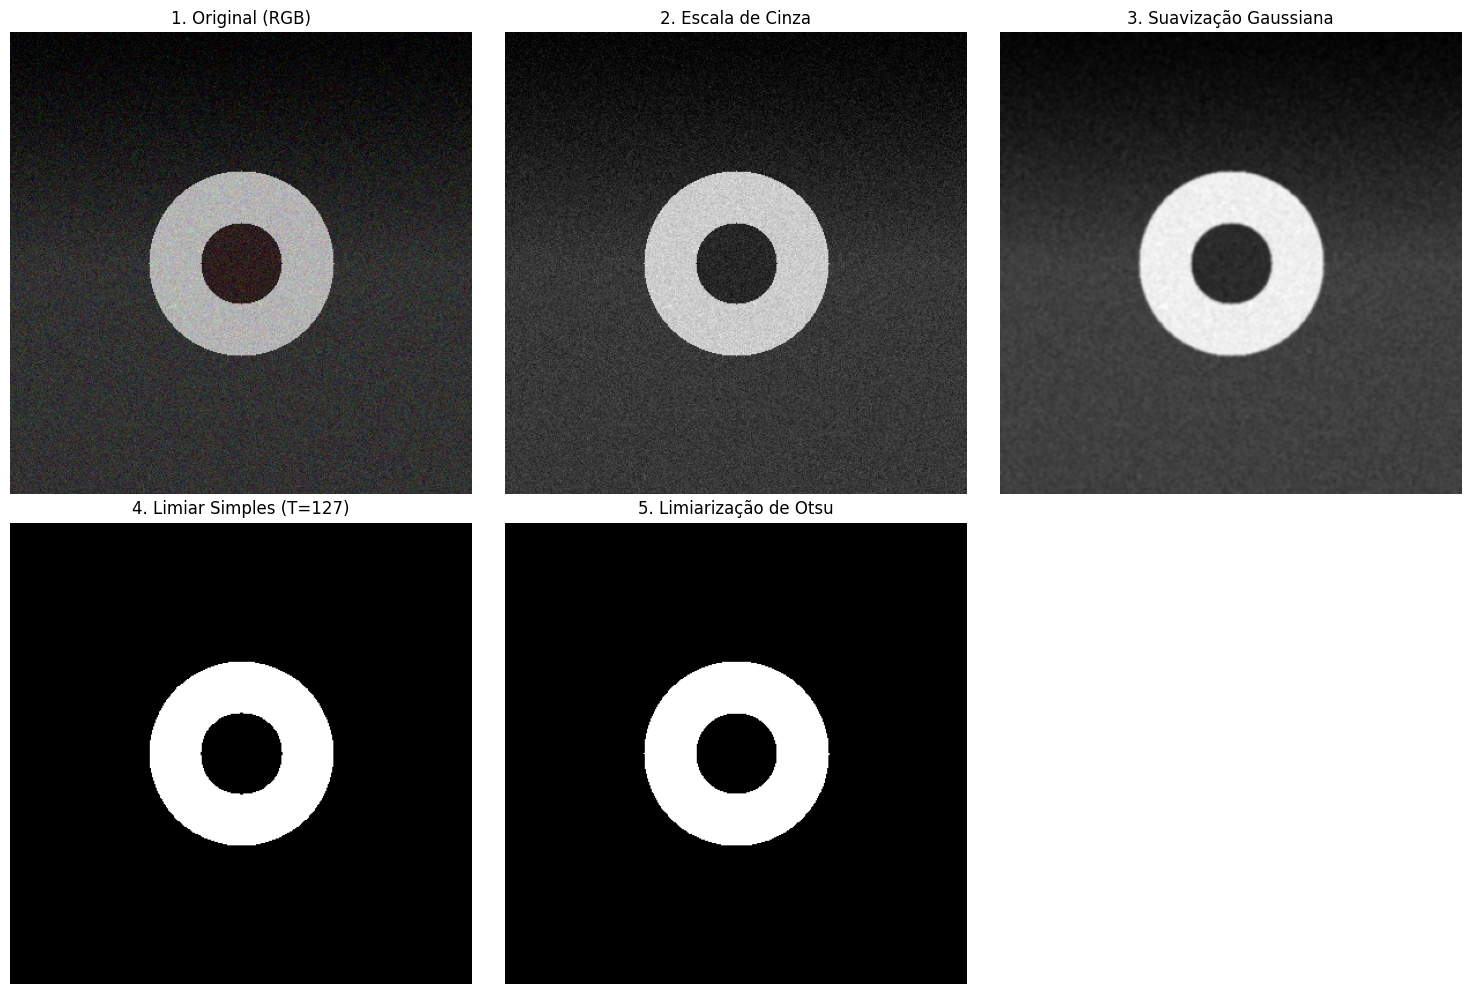

In [ ]:
fig, eixos = plt.subplots(2, 3, figsize=(15, 10))

eixos[0, 0].imshow(imagem_rgb)
eixos[0, 0].set_title("1. Original (RGB)")
eixos[0, 0].axis('off')

eixos[0, 1].imshow(imagem_cinza, cmap='gray')
eixos[0, 1].set_title("2. Escala de Cinza")
eixos[0, 1].axis('off')

eixos[0, 2].imshow(imagem_suavizada, cmap='gray')
eixos[0, 2].set_title("3. Suavização Gaussiana")
eixos[0, 2].axis('off')

eixos[1, 0].imshow(limiar_simples, cmap='gray')
eixos[1, 0].set_title("4. Limiar Simples (T=127)")
eixos[1, 0].axis('off')

eixos[1, 1].imshow(limiar_otsu, cmap='gray')
eixos[1, 1].set_title("5. Limiarização de Otsu")
eixos[1, 1].axis('off')

eixos[1, 2].axis('off')

plt.tight_layout()
plt.show()